# Visualisation of Dijkstra's algorithm

This notebook accompanies my lecture on Dijkstra's algorithm.

To run the notebook, you'll need to install GraphViz and the graphviz Python package with ``pip install graphviz``.

In [2]:
import graphviz
from collections import defaultdict
infinity = float('inf')

In [3]:
# Visualise the weighted graph
def visualise_weighted_graph(G, W):
    dot = graphviz.Graph()
    dot.attr(rankdir='LR')
    for name in G.keys():
        dot.node(name)
    for (u, v), w in W.items():
        if u<v:
            dot.edge(u, v, label=str(w))
    return dot

In [4]:
# Data structure is two dictionaries
G = defaultdict(list) # G[vertex] is a list of adjacent vertices
W = {} # W[u, v] = is weight from u to v

# Initialise from a list of strings
edges = ['AB1', 'AC2', 'BD1', 'BE4', 'CE1', 'EF3', 'FI1', 'EI1', 'EH1', 'HG1']
for u, v, w in edges:
    G[u].append(v)
    G[v].append(u)
    W[u,v] = W[v, u] = int(w)

# And visualise that
visualise_weighted_graph(G, W)

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [4]:
# For Dijkstra, we need a more complex visualisation that shows the current weights
# and predecessor subgraph
def visualise():
    dot = graphviz.Digraph()
    dot.attr(rankdir='LR')
    for name in G.keys():
        args = {}
        if name in q:
            args['label'] = f'{name}\ncur={q[name]}'
        if name in shortest:
            args['label'] = f'{name}\ndist={shortest[name]}'
            args['color'] = 'red'
            args['fontcolor'] = 'red'
        if name==vertex:
            args['color'] = 'blue'
        dot.node(name, **args)
    for (u, v), w in W.items():
        if u<v:
            dot.edge(u, v, label=str(w), dir='none')
    for target, source in predecessor.items():
        if source is not None:
            dot.edge(source, target, color='red')
    return dot

In [5]:
start = 'A'                   # where shortest paths start
predecessor = {start: None}   # predecessor subgraph (start has no predecessor)
q = {start: 0}                # priority queue for next vertices, distance to start is 0
shortest = {}                 # shortest paths found (none at the start)

Finished!


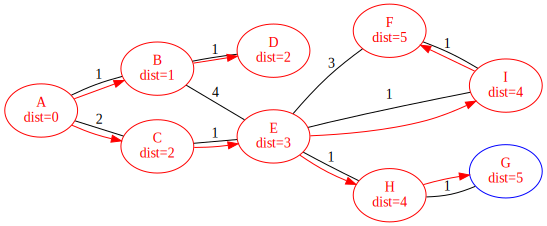

In [14]:
# Repeatedly evaluate this cell until it says Finished!
if q: # are there any vertices to add?
    # Find the lowest priority (note: this is where the data structure is inefficient!)
    d, vertex = min((d, vertex) for vertex, d in q.items())
    del q[vertex]
    # Add this to the set of vertices we've finished processing
    shortest[vertex] = d
    # Now update the list of candidate vertices by iterating through its neighbours
    for next_vertex in G[vertex]:
        if next_vertex in shortest: # don't add ones we've already finished with
            continue
        c = q.get(next_vertex, infinity) # get the current best found if there is one, or infinity if not
        e = d+W[vertex, next_vertex] # distance to next_vertex if you take this route
        if e<c: # if it's better, replace it in the queue and predecessor subgraph
            q[next_vertex] = e
            predecessor[next_vertex] = vertex
if not q:
    print('Finished!')
visualise()

<p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p>
<p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p>
<p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p><p>&nbsp;</p>